# Data Understanding — DataCo Smart Supply Chain for Data Analysis

**Project phase:** Data Understanding (CRISP-DM Phase 2)
**Dataset:** DataCo Smart Supply Chain for Data Analysis — 180,519 orders x 53 features (2015-2018)
**Analyst:** Akash More

## Business Context
DataCo is a global retailer operating across 5 markets (LATAM, Europe, Pacific Asia, USCA, Africa) and 164 countries.
Two recurring problems stand out in the data: late deliveries and inconsistent order profitability. Before doing
any cleaning or modeling, the goal of this notebook is to understand the data itself - its structure, its quality,
and what it actually means in business terms - so that later decisions (feature engineering, forecasting,
segmentation) are built on a solid base.

## Objectives of this notebook
1. Get the structural profile of the dataset (volume, types, memory footprint).
2. Measure data quality - missing values, duplicates, and logical consistency.
3. Profile categorical cardinality and time coverage to understand what's usable.
4. Identify possible target variables and the business KPIs the data can support.
5. Look for early signals (correlations, anomalies) that will shape the cleaning and EDA plan.
6. Build a data dictionary and a list of issues to fix before modeling.


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42

In [2]:
df_raw = pd.read_csv("DataCoSupplyChainDataset.csv", encoding="ISO-8859-1")

df = df_raw.copy()
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

Rows: 180,519  |  Columns: 53


## 2. Structural Overview

Shape, dtypes, and memory footprint - this tells us whether pandas alone is enough or if later steps will need
chunking or a database engine.

In [3]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [4]:
memory_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"Total in-memory size: {memory_mb:.2f} MB")

dtype_summary = df.dtypes.value_counts().rename("column_count").to_frame()
dtype_summary

Total in-memory size: 298.92 MB


,column_count
object,24
float64,15
int64,14


In [5]:
df.head(5)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [6]:
# Random sample rather than head() alone — head() can hide patterns that
# only show up mid-file (e.g. this data is roughly time-ordered).
df.sample(5, random_state=RANDOM_STATE)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
80120,TRANSFER,5,4,11.090000,175.990005,Late delivery,1,48,Water Sports,Caguas,Puerto Rico,XXXXXXXXX,Zachary,6109,Tate,XXXXXXXXX,Consumer,PR,8916 Round Zephyr Ridge,725.0,7,Fan Shop,18.203976,-66.370544,USCA,Los Angeles,Estados Unidos,6109,4/1/2016 21:05,31299,1073,24.0,0.12,78239,199.990005,0.06,1,199.990005,175.990005,11.090000,West of USA,California,PROCESSING,90036.0,1073,48,NaN,http://images.acmesports.sports/Pelican+Sunstr...,Pelican Sunstream 100 Kayak,199.990005,0,4/6/2016 21:05,Standard Class
19670,PAYMENT,2,1,9.800000,245.000000,Late delivery,1,24,Women's Apparel,Florissant,EE. UU.,XXXXXXXXX,Gary,12041,Oneal,XXXXXXXXX,Consumer,MO,372 Sunny Arbor,63033.0,5,Golf,38.807110,-90.297806,LATAM,Tegucigalpa,Honduras,12041,6/9/2017 18:43,61023,502,5.0,0.02,152658,50.000000,0.04,5,250.000000,245.000000,9.800000,Central America,Francisco Morazán,PENDING_PAYMENT,NaN,502,24,NaN,http://images.acmesports.sports/Nike+Men%27s+D...,Nike Men's Dri-FIT Victory Golf Polo,50.000000,0,6/11/2017 18:43,First Class
114887,TRANSFER,2,4,117.550003,244.899994,Advance shipping,0,46,Indoor/Outdoor Games,Carmichael,EE. UU.,XXXXXXXXX,Andrea,4271,Alexander,XXXXXXXXX,Corporate,CA,2407 Foggy Acres,95608.0,7,Fan Shop,38.608032,-121.321953,LATAM,Tijuana,México,4271,1/2/2015 14:32,111,1014,5.0,0.02,253,49.980000,0.48,5,249.899994,244.899994,117.550003,Central America,Baja California,PROCESSING,NaN,1014,46,NaN,http://images.acmesports.sports/O%27Brien+Men%...,O'Brien Men's Neoprene Life Vest,49.980000,0,1/4/2015 14:32,Standard Class
120110,TRANSFER,5,4,118.430000,251.979996,Late delivery,1,43,Camping & Hiking,Troy,EE. UU.,XXXXXXXXX,Joyce,3521,Callahan,XXXXXXXXX,Consumer,NY,4075 Silver Hills Heights,12180.0,7,Fan Shop,42.730049,-73.689529,Africa,Pretoria,SudAfrica,3521,1/10/2017 1:46,50699,957,48.0,0.16,126700,299.980011,0.47,1,299.980011,251.979996,118.430000,Southern Africa,Gauteng,PENDING,NaN,957,43,NaN,http://images.acmesports.sports/Diamondback+Wo...,Diamondback Women's Serene Classic Comfort Bi,299.980011,0,1/15/2017 1:46,Standard Class
56658,DEBIT,2,4,-21.590000,107.970001,Advance shipping,0,29,Shop By Sport,Caguas,Puerto Rico,XXXXXXXXX,Mildred,12073,Merritt,XXXXXXXXX,Consumer,PR,4661 Green Freeway,725.0,5,Golf,18.234550,-66.370575,LATAM,Santiago de los Caballeros,República Dominicana,12073,4/6/2017 7:15,56606,627,12.0,0.10,141586,39.990002,-0.20,3,119.970001,107.970001,-21.590000,Caribbean,Santiago de Chile,COMPLETE,NaN,627,29,NaN,http://images.acmesports.sports/Under+Armour+G...,Under Armour Girls' Toddler Spine Surge Runni,39.990002,0,4/8/2017 7:15,Standard Class


## 3. Column-Level Profile

One reference table combining dtype, cardinality, missingness, and a sample value per column. This becomes the
data dictionary in Section 9, and it's the fastest way to spot problems - e.g. a column typed `object` that should
be numeric, or a column with `nunique() == 1` that carries no information.

In [7]:
profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null_count": df.notnull().sum(),
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().mean() * 100).round(2),
    "n_unique": df.nunique(),
    "sample_value": df.iloc[0],
})
profile["is_constant"] = profile["n_unique"] <= 1
profile.sort_values("missing_pct", ascending=False)

,dtype,non_null_count,missing_count,missing_pct,n_unique,sample_value,is_constant
Product Description,float64,0,180519,100.00,0,NaN,True
Order Zipcode,float64,24840,155679,86.24,609,NaN,False
Days for shipment (scheduled),int64,180519,0,0.00,4,4,False
Days for shipping (real),int64,180519,0,0.00,7,3,False
Type,object,180519,0,0.00,4,DEBIT,False
Delivery Status,object,180519,0,0.00,4,Advance shipping,False
Late_delivery_risk,int64,180519,0,0.00,2,0,False
Category Id,int64,180519,0,0.00,51,73,False
Category Name,object,180519,0,0.00,50,Sporting Goods,False
Customer City,object,180519,0,0.00,563,Caguas,False


In [8]:
constant_cols = profile.loc[profile["is_constant"]].index.tolist()
print("Zero-information (constant) columns — candidates to drop:")
print(constant_cols)

Zero-information (constant) columns — candidates to drop:
['Customer Email', 'Customer Password', 'Product Description', 'Product Status']


## 4. Descriptive Statistics

### 4.1 Numeric features
Min/max/mean alone hides skew and outliers. That matters here because `Benefit per order` and
`Order Profit Per Order` can be negative (loss-making orders) - that's a real business signal, not a data error.

In [9]:
numeric_summary = df.describe().T
numeric_summary["skew"] = df.select_dtypes(include=np.number).skew()
numeric_summary["missing_pct"] = (df.isnull().mean() * 100).round(2)[numeric_summary.index]
numeric_summary[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "skew", "missing_pct"]].round(2)

,count,mean,std,min,25%,50%,75%,max,skew,missing_pct
Days for shipping (real),180519.0,3.50,1.62,0.00,2.00,3.00,5.00,6.00,0.08,0.00
Days for shipment (scheduled),180519.0,2.93,1.37,0.00,2.00,4.00,4.00,4.00,-0.73,0.00
Benefit per order,180519.0,21.97,104.43,-4274.98,7.00,31.52,64.80,911.80,-4.74,0.00
Sales per customer,180519.0,183.11,120.04,7.49,104.38,163.99,247.40,1939.99,2.89,0.00
Late_delivery_risk,180519.0,0.55,0.50,0.00,0.00,1.00,1.00,1.00,-0.19,0.00
Category Id,180519.0,31.85,15.64,2.00,18.00,29.00,45.00,76.00,0.36,0.00
Customer Id,180519.0,6691.38,4162.92,1.00,3258.50,6457.00,9779.00,20757.00,0.49,0.00
Customer Zipcode,180516.0,35921.13,37542.46,603.00,725.00,19380.00,78207.00,99205.00,0.49,0.00
Department Id,180519.0,5.44,1.63,2.00,4.00,5.00,7.00,12.00,0.27,0.00
Latitude,180519.0,29.72,9.81,-33.94,18.27,33.14,39.28,48.78,-0.10,0.00


In [10]:
# Loss-making orders — a direct business KPI, visible only by looking beyond min/max.
loss_orders = df[df["Benefit per order"] < 0]
print(f"Orders with negative profit: {len(loss_orders):,} ({len(loss_orders)/len(df)*100:.1f}% of all orders)")

Orders with negative profit: 33,784 (18.7% of all orders)


### 4.2 Categorical features
`describe(include='object')` on the low/medium-cardinality columns that will likely become groupby/segmentation
dimensions later on (Market, Category, Customer Segment, Shipping Mode, Order Status).

In [11]:
key_categoricals = [
    "Type", "Delivery Status", "Customer Segment",
    "Market", "Order Region", "Order Status", "Shipping Mode", "Department Name",
]
df[key_categoricals].describe().T

,count,unique,top,freq
Type,180519,4,DEBIT,69295
Delivery Status,180519,4,Late delivery,98977
Customer Segment,180519,3,Consumer,93504
Market,180519,5,LATAM,51594
Order Region,180519,23,Central America,28341
Order Status,180519,9,COMPLETE,59491
Shipping Mode,180519,4,Standard Class,107752
Department Name,180519,11,Fan Shop,66861


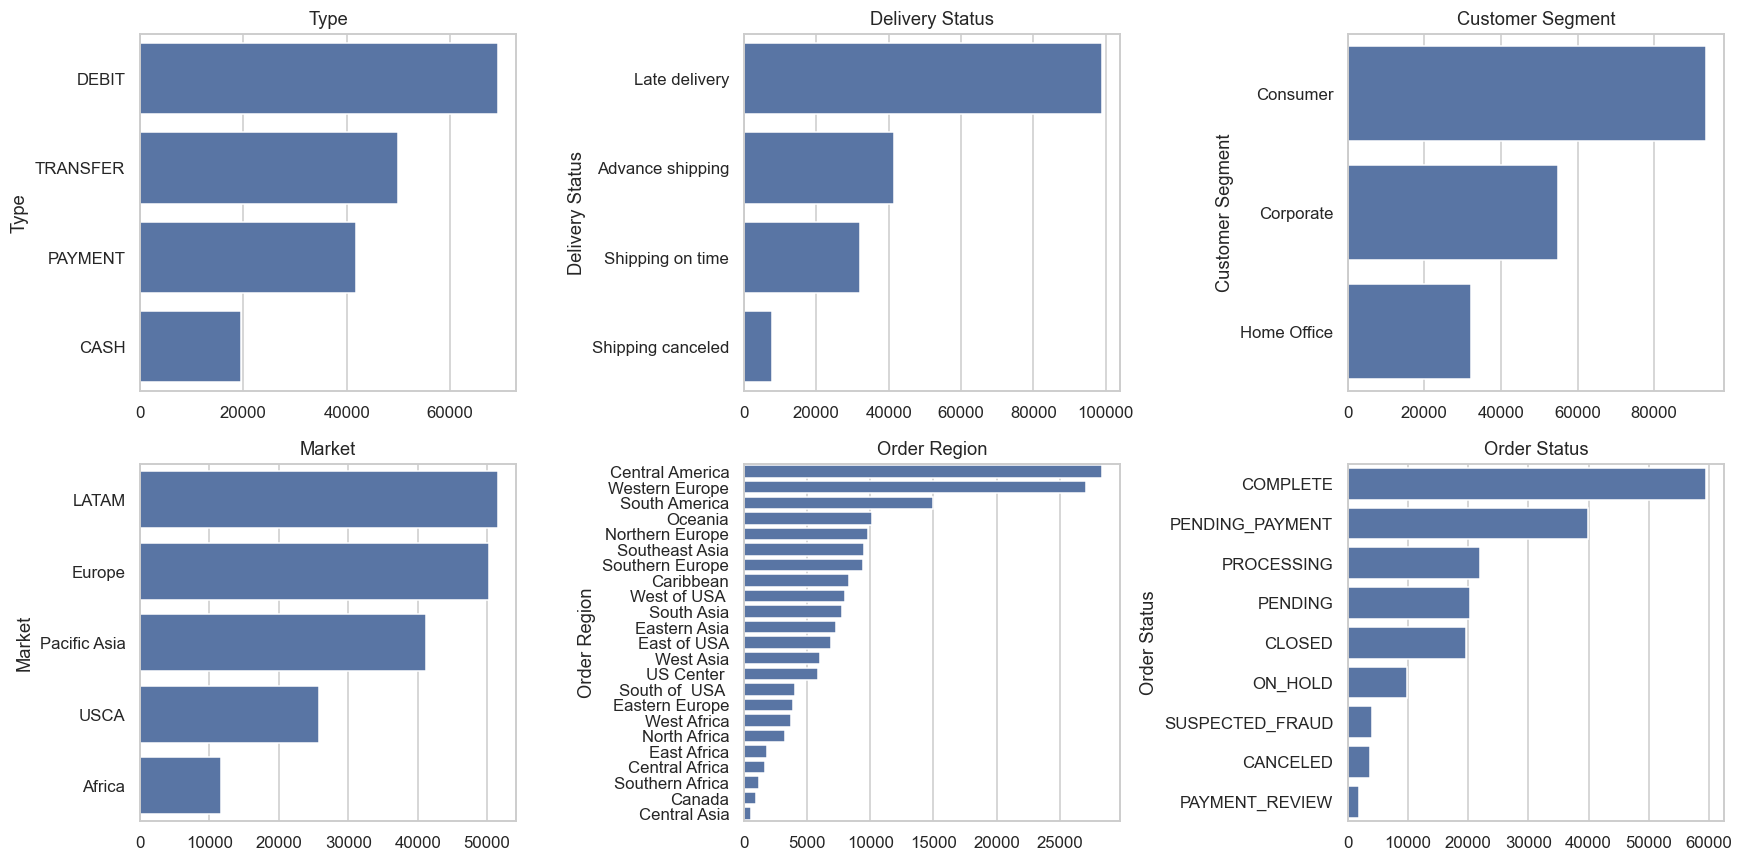

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, key_categoricals[:6]):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 5. Data Quality Assessment

### 5.1 Missing values

In [13]:
missing_report = profile.loc[profile["missing_count"] > 0, ["missing_count", "missing_pct"]]
missing_report = missing_report.sort_values("missing_pct", ascending=False)
missing_report

,missing_count,missing_pct
Product Description,180519,100.00
Order Zipcode,155679,86.24
Customer Zipcode,3,0.00
Customer Lname,8,0.00


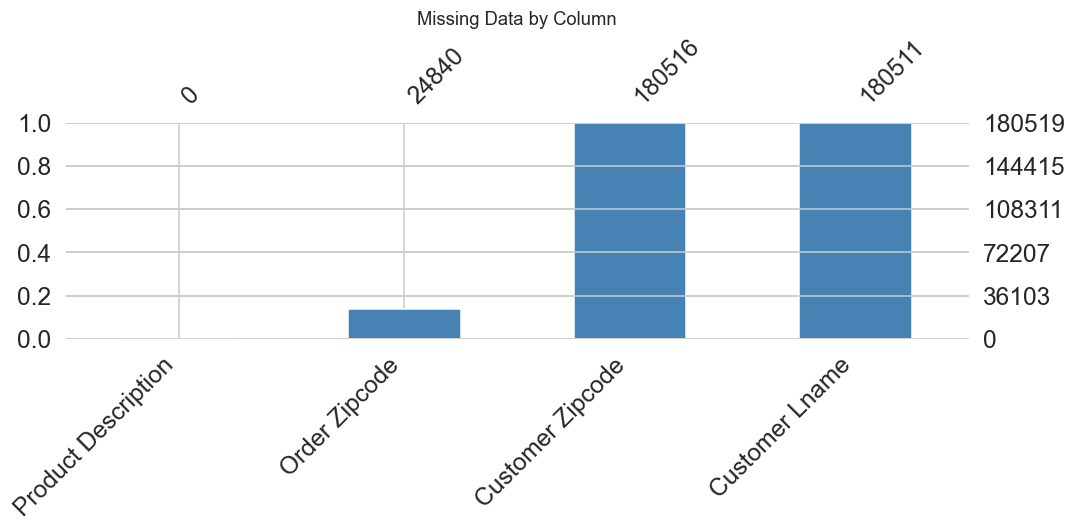

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
msno.bar(df[missing_report.index], ax=ax, color="steelblue")
plt.title("Missing Data by Column",fontsize=12)

plt.tight_layout()
plt.show()

**Reading the missingness, column by column:**
- `Product Description` - 100% missing -> drop; carries no information.
- `Order Zipcode` - very high missingness, and largely redundant with `Order City` / `Order State` / lat-long -> drop
  or treat as "unknown" if zip-level granularity is ever needed.
- `Customer Lname`, `Customer Zipcode`, `Customer Street` - low missingness, likely safe to impute or drop rows.
- `Customer Email`, `Customer Password` - fully masked (`XXXXXXXXX`); not missing, but not usable, and should be
  dropped since they're PII with no analytical value.

### 5.2 Duplicate records

In [15]:
n_dupe_rows = df.duplicated().sum()
n_dupe_order_items = df.duplicated(subset=["Order Item Id"]).sum()
print(f"Fully duplicated rows: {n_dupe_rows}")
print(f"Duplicate Order Item Id (should be a unique key): {n_dupe_order_items}")

Fully duplicated rows: 0
Duplicate Order Item Id (should be a unique key): 0


### 5.3 Logical / referential consistency
Beyond checking for empty cells, it's worth checking whether the data makes internal sense.

In [16]:
checks = {}

# a) Shipping date should never precede order date.
checks["shipping_before_order"] = (
    pd.to_datetime(df["shipping date (DateOrders)"]) < pd.to_datetime(df["order date (DateOrders)"])
).sum()

# b) Days for shipping (real) should be non-negative and consistent with the date delta.
checks["negative_shipping_days"] = (df["Days for shipping (real)"] < 0).sum()

# c) Sales should equal Product Price * Quantity (within rounding) — flags pricing/data-entry errors.
implied_sales = df["Order Item Product Price"] * df["Order Item Quantity"]
checks["sales_mismatch_gt_1pct"] = (
    (df["Sales"] - implied_sales).abs() / df["Sales"].replace(0, np.nan) > 0.01
).sum()

# d) Late_delivery_risk (binary flag) should agree with Delivery Status == 'Late delivery'.
checks["late_flag_inconsistent"] = (
    (df["Late_delivery_risk"] == 1) != (df["Delivery Status"] == "Late delivery")
).sum()

pd.Series(checks, name="flagged_rows").to_frame()

,flagged_rows
shipping_before_order,0
negative_shipping_days,0
sales_mismatch_gt_1pct,0
late_flag_inconsistent,0


### 5.4 Outlier scan
A quick IQR-based scan on the core financial fields, just to flag extreme values for the cleaning stage - not to
remove anything here. Some "outliers" (e.g. very high-value B2B orders) may be real and business-relevant.

In [17]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

financial_cols = ["Sales", "Order Item Discount", "Order Profit Per Order", "Order Item Profit Ratio"]
pd.Series({c: iqr_outlier_count(df[c]) for c in financial_cols}, name="iqr_outlier_count").to_frame()

,iqr_outlier_count
Sales,488
Order Item Discount,7537
Order Profit Per Order,18942
Order Item Profit Ratio,17300


## 6. Temporal Coverage

Any forecasting or trend work later depends on knowing the exact time window - and any gaps - in the data.

Order date range:  2015-01-01 00:00:00 → 2018-01-31 23:38:00
Shipping date range: 2015-01-03 00:00:00 → 2018-02-06 22:14:00


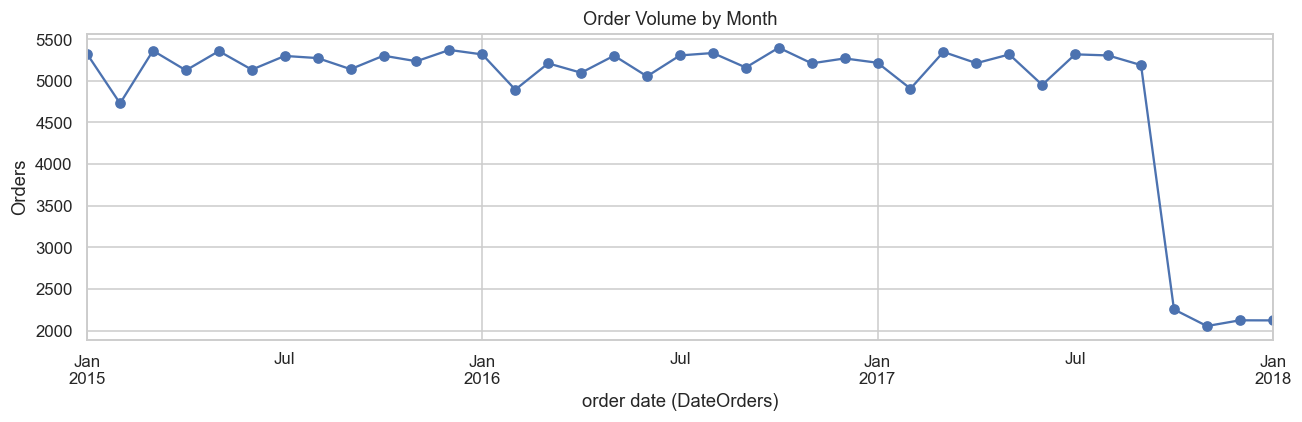

In [18]:
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"])
df["shipping date (DateOrders)"] = pd.to_datetime(df["shipping date (DateOrders)"])

print("Order date range: ", df["order date (DateOrders)"].min(), "→", df["order date (DateOrders)"].max())
print("Shipping date range:", df["shipping date (DateOrders)"].min(), "→", df["shipping date (DateOrders)"].max())

orders_per_month = df.set_index("order date (DateOrders)").resample("ME").size()
orders_per_month.plot(figsize=(12, 4), title="Order Volume by Month", marker="o")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()

## 7. Candidate Target Variables & Business KPIs

Mapping business questions to possible targets, so the next phase has a clear direction instead of just a pile
of columns.

| Business question | Candidate target | Task type |
|---|---|---|
| Will this order arrive late? | `Late_delivery_risk` / `Delivery Status` | Classification |
| How profitable will this order be? | `Order Profit Per Order` / `Order Item Profit Ratio` | Regression |
| What will next month's sales be, by region/category? | `Sales` (aggregated) | Time-series forecasting |
| Which customer segment/market drives the most loss? | `Order Profit Per Order` grouped by `Customer Segment`/`Market` | Segmentation / diagnostic analytics |


In [19]:
print(df["Delivery Status"].value_counts(normalize=True).round(3) * 100)
print()
print(df["Late_delivery_risk"].value_counts(normalize=True).round(3) * 100)

Delivery Status
Late delivery        54.8
Advance shipping     23.0
Shipping on time     17.8
Shipping canceled     4.3
Name: proportion, dtype: float64

Late_delivery_risk
1    54.8
0    45.2
Name: proportion, dtype: float64


## 8. Correlation Snapshot (Numeric Features)

An early look, mainly to see which relationships are worth digging into during EDA, and to flag redundant features
(e.g. `Sales` vs `Order Item Total` vs `Product Price` are likely near-duplicates of each other).

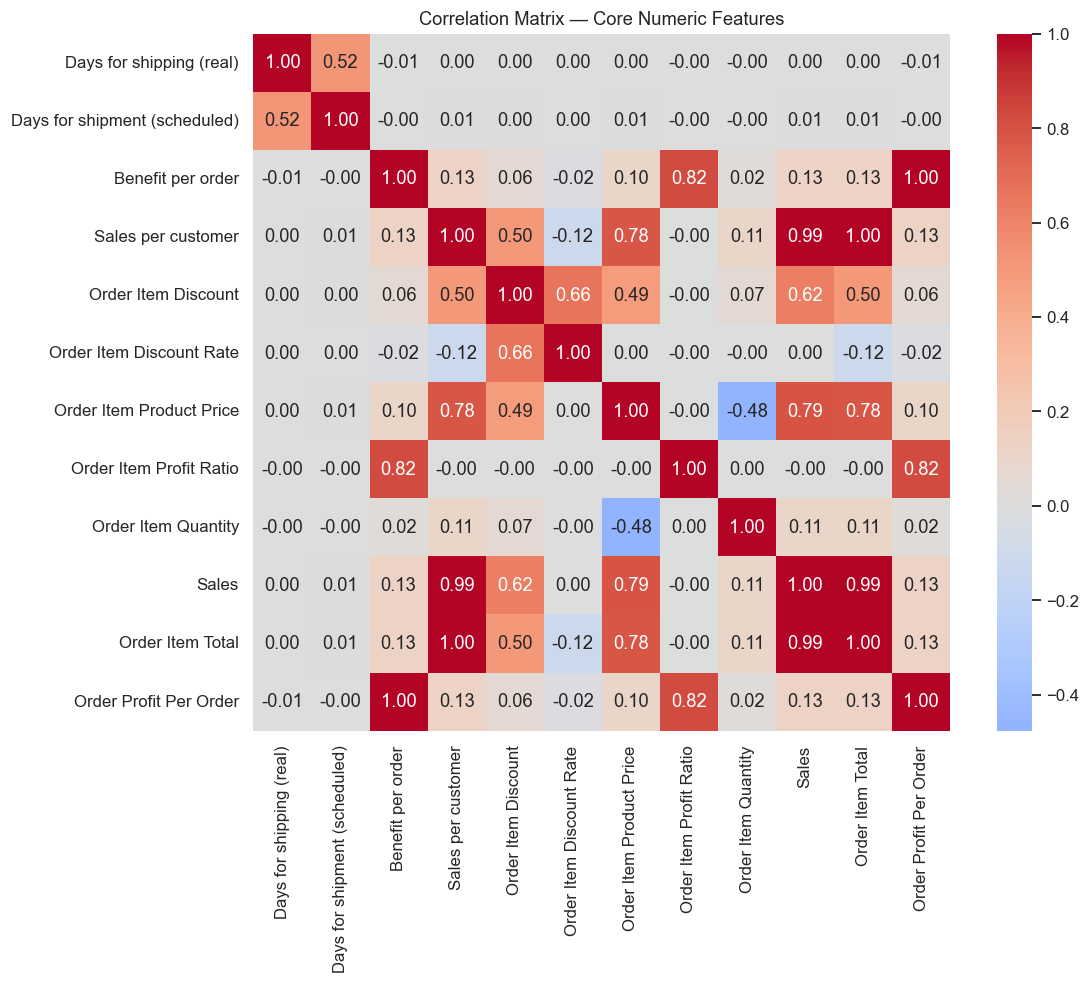

In [20]:
numeric_cols = [
    "Days for shipping (real)", "Days for shipment (scheduled)", "Benefit per order",
    "Sales per customer", "Order Item Discount", "Order Item Discount Rate",
    "Order Item Product Price", "Order Item Profit Ratio", "Order Item Quantity",
    "Sales", "Order Item Total", "Order Profit Per Order",
]

plt.figure(figsize=(11, 9))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix — Core Numeric Features")
plt.tight_layout()
plt.show()

## 9. Key Findings & Data Cleaning Plan

**Structure**
- 180,519 rows x 53 columns; ~2015-2018 order history across 5 markets / 164 countries.
- No fully duplicated rows; `Order Item Id` is a clean unique key.

**Quality issues found**
- `Product Description` (100% missing) and `Order Zipcode` (very high missingness) -> drop.
- `Customer Email` / `Customer Password` are masked PII with zero analytical value -> drop.
- A few logical-consistency checks (Section 5.3) flagged rows to review - e.g. any `shipping_before_order` or
  `sales_mismatch` cases need a decision: correct, drop, or flag-and-keep.
- `Order Profit Per Order` / `Benefit per order` are frequently negative - a real business signal (loss-making
  orders), not a data error; should not be filtered out as "outliers" without checking with the business first.
- Several column pairs are near-duplicates (`Sales` vs `Order Item Total`; `Order Item Product Price` vs
  `Product Price`) - one from each pair should be dropped before modeling to avoid multicollinearity.